In [1]:
import orbit #общий пакет
from orbit.models import DLT #один из вариантов модели
from orbit.diagnostics.plot import plot_predicted_data, plot_predicted_components #для рисования предсказаний

import pandas as pd
import pandahouse as ph
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

import arviz as az #для визуализации MCMC

from causalimpact import CausalImpact

from orbit.diagnostics.backtest import BackTester #основной класс для бэктестинга 
from orbit.utils.params_tuning import grid_search_orbit #для подбора оптимальных параметров

2026-04-07 12:12:43.991775: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 12:12:44.047657: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 12:12:44.993247: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [40]:
 connection = {
    'host': 'host-address',
    'database':'simulator_20260120',
    'user': 'user', 
    'password': 'pass'
}

In [3]:
query = '''
SELECT
    toDate(time) AS day,
    count(action) AS actions,
    CASE WHEN (day BETWEEN '2026-01-15' AND '2026-01-22') 
        THEN 1
        ELSE 0
    END AS unusual_day
FROM {db}.feed_actions 
WHERE day < '2026-03-01'
GROUP BY day
ORDER BY day
'''

In [4]:
df = ph.read_clickhouse(query=query, connection=connection)
df.tail(10)

,day,actions,unusual_day
75,2026-02-19,755837,0
76,2026-02-20,716396,0
77,2026-02-21,610623,0
78,2026-02-22,688143,0
79,2026-02-23,751990,0
80,2026-02-24,869319,0
81,2026-02-25,955103,0
82,2026-02-26,878711,0
83,2026-02-27,856806,0
84,2026-02-28,909454,0


В качестве метрики для прогнозирования взяла все действия пользователей в ленте, так как именно число действий напрямую влияет на загруженность серверов. Грануляция по дням, так как горизонт планирования большой (30 дней), разбивка по часам была бы слишком перегруженной для обучения. Дополнительным регрессором в моделях является бинарный показатель, минимизирующий влияние "выбросов" в данных, связанных с рекламной кампанией и флешмобом, в эти дни наблюдались пики активности. 

In [5]:
df["day"] = pd.to_datetime(df["day"])

<Axes: xlabel='day', ylabel='actions'>

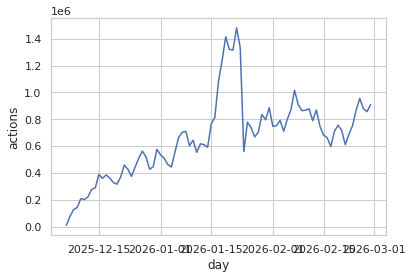

In [6]:
sns.set(rc={'figure.figsize':(20,10)}, style="whitegrid")
sns.lineplot(x="day", y="actions", data=df)

Модель DLT, алгоритм MAP 
Оптимальным damped_factor для нее является 0.6, это рассчитано ниже

In [7]:
dlt = DLT(response_col="actions", #название колонки с метрикой
          date_col="day", #название колонки с датами-временем
          damped_factor=0.6, 
          estimator="stan-map", #алгоритм оценки
          n_bootstrap_draws=1000, #количество сэмплов бутстрапа для доверительного интервала
          ) 

2026-04-07 12:12:47 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


In [8]:
dlt.fit(df)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

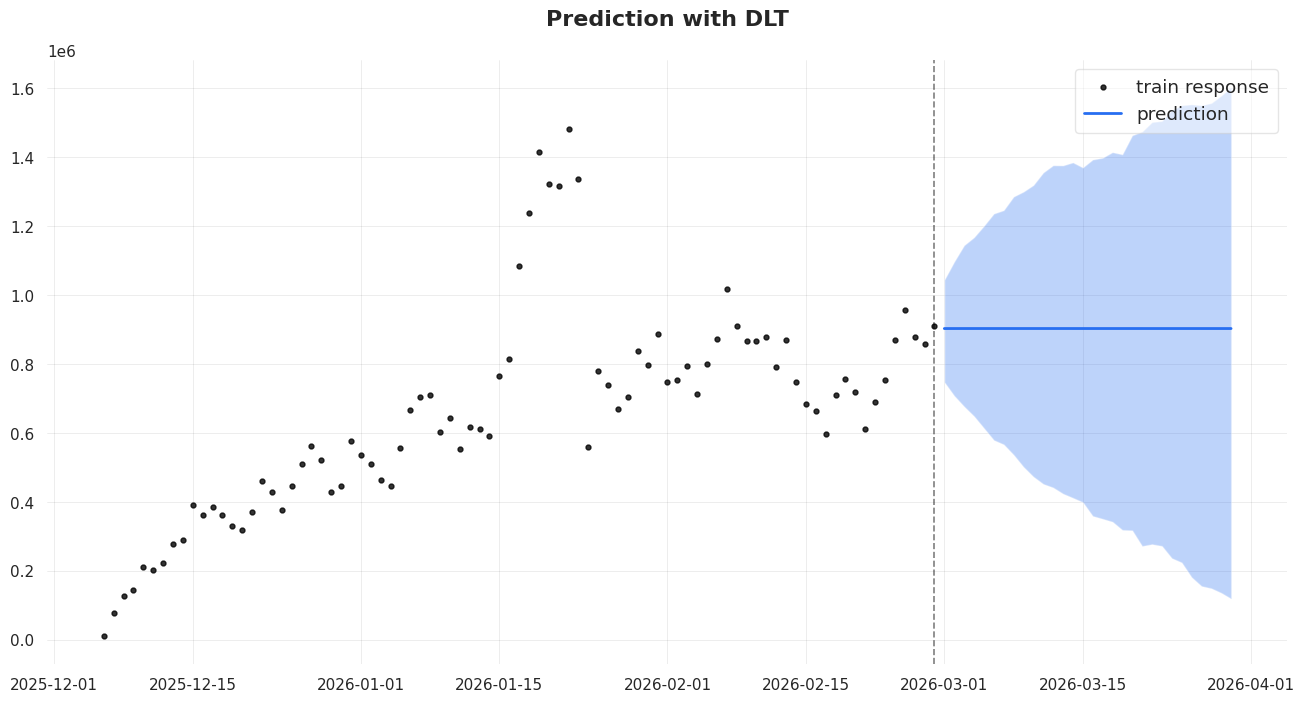

In [9]:
future_df = dlt.make_future_df(periods=30)

predicted_df = dlt.predict(df=future_df)

_ = plot_predicted_data(df, predicted_df, "day", 'actions', title='Prediction with DLT')

In [10]:
best_params, tuned_df = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр
                                        model=dlt,
                                        df=df,
                                        min_train_len=14,
                                        incremental_len=1,
                                        forecast_len=30,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-04-07 12:12:48 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-04-07 12:12:48 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:12:52 - orbit - INFO - tuning metric:0.33586
2026-04-07 12:12:52 - orbit - INFO - tuning hyper-params {'damped_factor': 0.2}
2026-04-07 12:12:52 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:12:56 - orbit - INFO - tuning metric:0.36452
2026-04-07 12:12:56 - orbit - INFO - tuning hyper-params {'damped_factor': 0.30000000000000004}
2026-04-07 12:12:56 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:00 - orbit - INFO - tuning metric:0.32973
2026-04-07 12:13:00 - orbit - INFO - tuning hyper-params {'damped_factor': 0.4}
2026-04-07 12:13:00 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:04 - orbit - INFO - tuning metric:0.32601
2026-04-07 12:13:04 - orbit - INFO - tuning hyper-params {'damped_factor': 0.5}
2026-04-07 12:13:04 - orbit 

In [11]:
best_params, tuned_df

([{'damped_factor': 0.6}],
    damped_factor   metrics
 0            0.1  0.335860
 1            0.2  0.364516
 2            0.3  0.329729
 3            0.4  0.326014
 4            0.5  0.324616
 5            0.6  0.322271
 6            0.7  0.346214
 7            0.8  0.367394
 8            0.9  0.346043)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

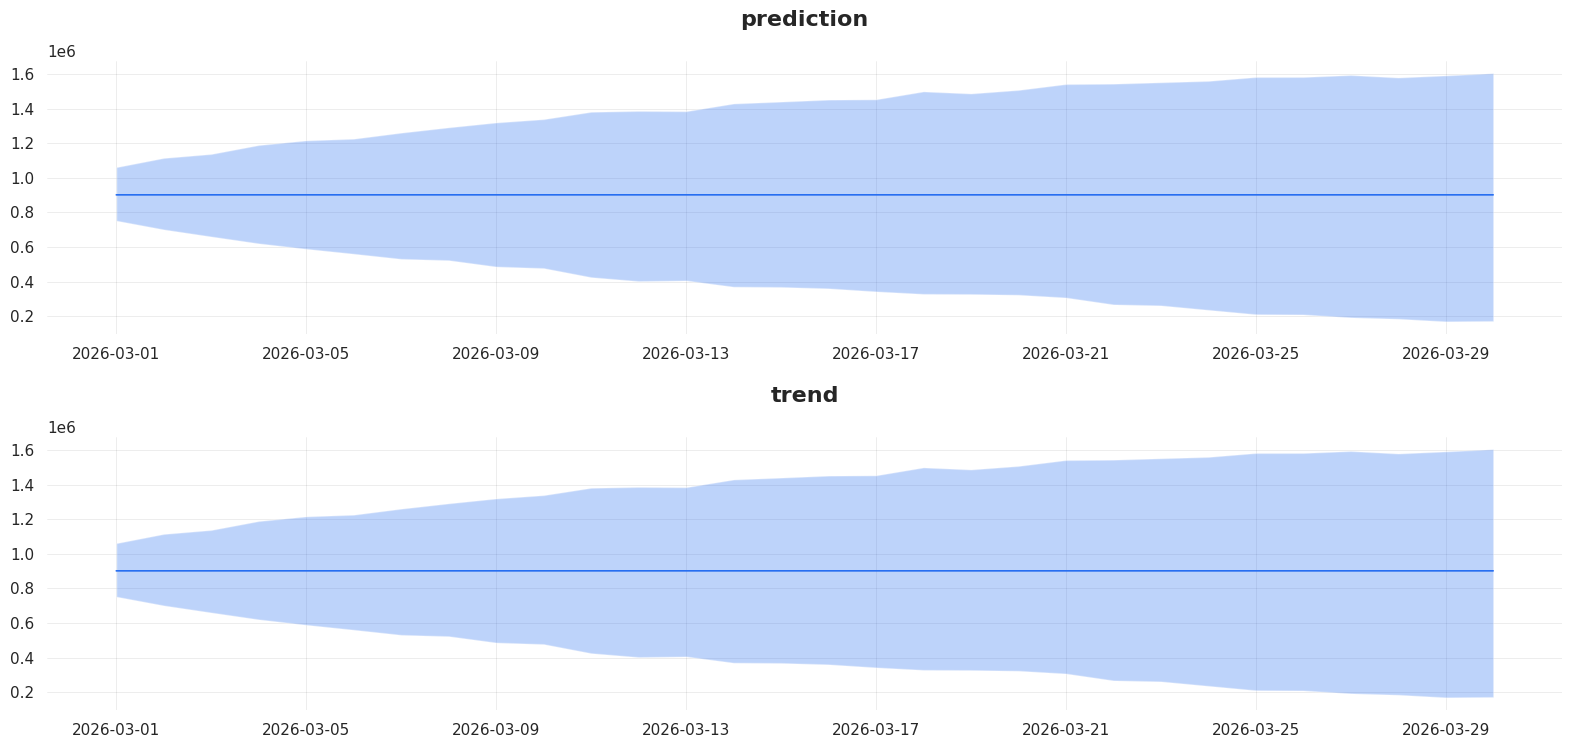

In [12]:
predicted_df = dlt.predict(df=future_df, 
                           decompose=True) #говорит, что нам нужна декомпозиция предсказания

_ = plot_predicted_components(predicted_df, "day", plot_components=['prediction', 'trend'])

Модель DLT, алгоритм MCMC 

In [13]:
dlt_mcmc = DLT(response_col="actions", date_col="day", 
               estimator='stan-mcmc', #новый алгоритм оценки
               num_warmup=2000, #время "разогрева"
               num_sample=1000) #время сэмплирования

In [14]:
dlt_mcmc.fit(df)

2026-04-07 12:13:26 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

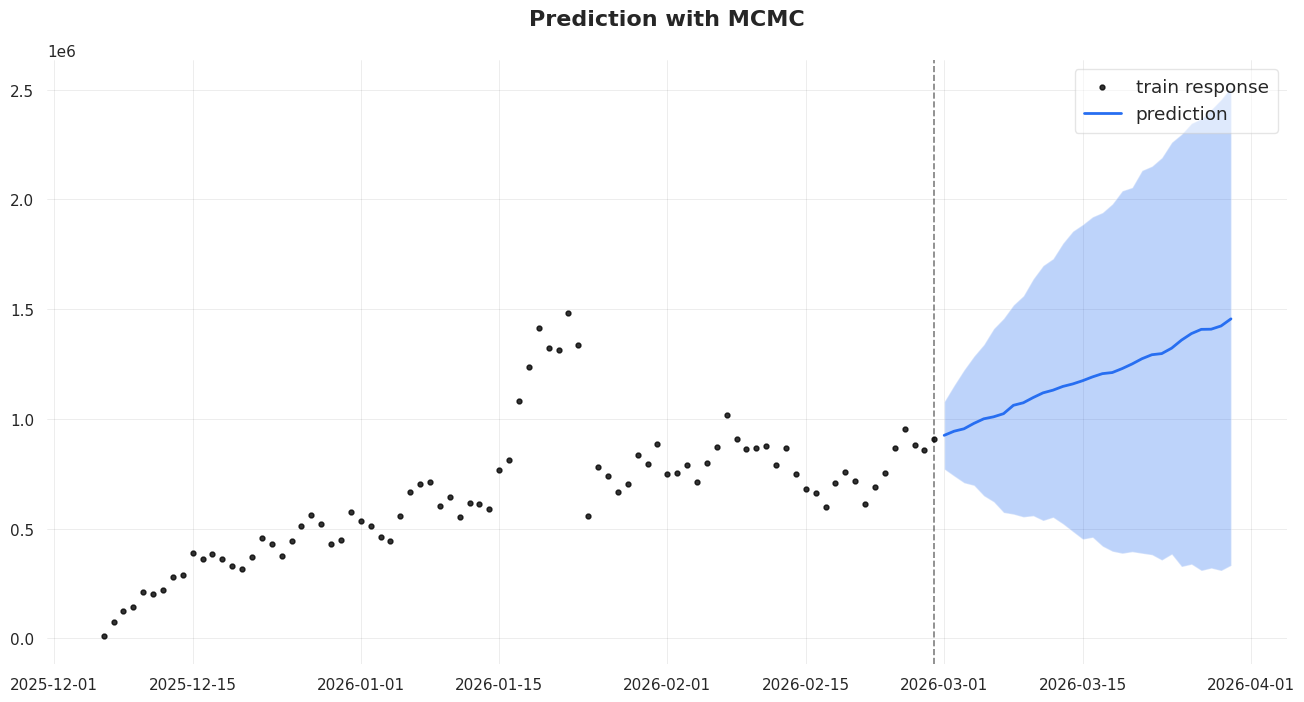

In [15]:
future_df_mcmc = dlt_mcmc.make_future_df(periods=30)

predicted_df_mcmc = dlt_mcmc.predict(df=future_df_mcmc)

_ = plot_predicted_data(df, predicted_df_mcmc, "day", 'actions', title='Prediction with MCMC')

Алгоритм mcmc дает восходящий тренд, а dlt - нулевой. Очень широкие доверительные интервалы, что говорит о высокой степени неопределенности, увеличивающейся с каждым предсказанным днем. 

Модели DLT с бинарным регрессором 

In [16]:
reg_model = DLT(response_col="actions",
                date_col="day", 
                damped_factor=0.1,
                estimator="stan-map", 
                n_bootstrap_draws=1000, 
                regressor_col=["unusual_day"]
               )

2026-04-07 12:13:32 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


In [17]:
reg_model.fit(df)

In [18]:
future_df_reg = reg_model.make_future_df(periods=30)
future_df_reg['unusual_day'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

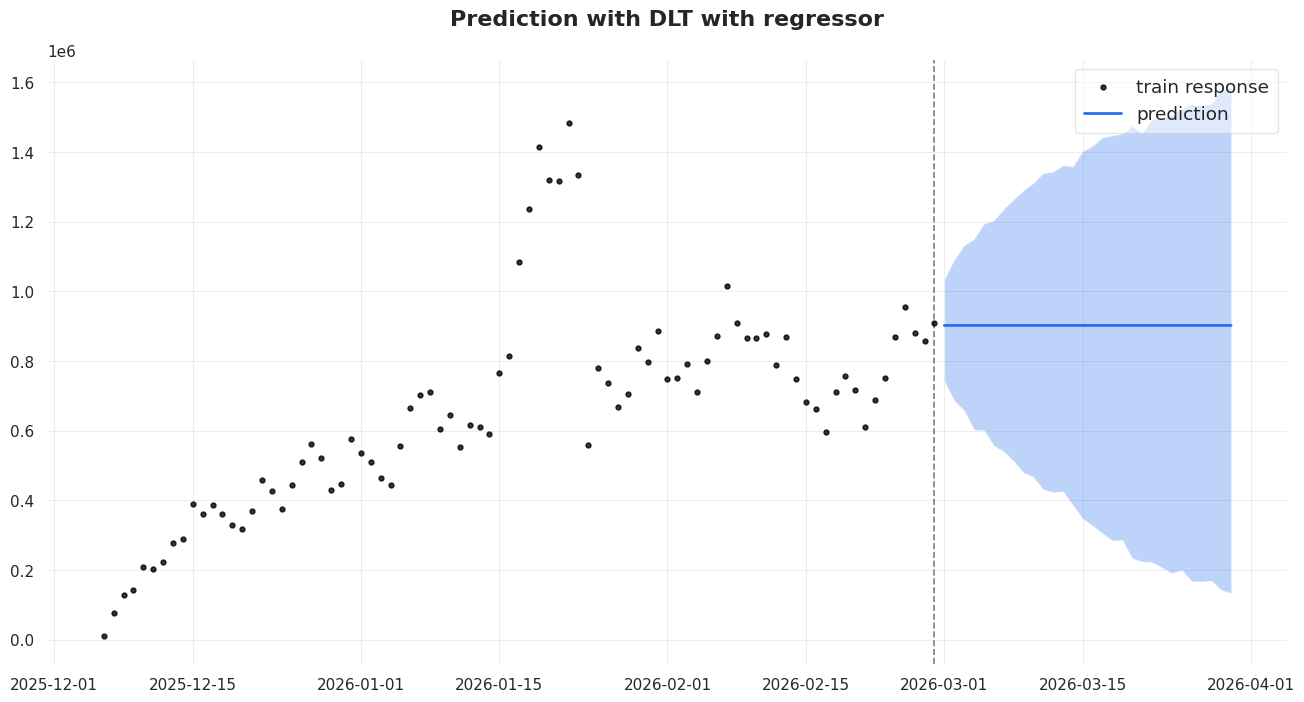

In [19]:
predicted_df_reg = reg_model.predict(df=future_df_reg)

_ = plot_predicted_data(df, predicted_df_reg, "day", 'actions', title='Prediction with DLT with regressor')

In [20]:
best_params, tuned_df = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр
                                        model=reg_model,
                                        df=df,
                                        min_train_len=14,
                                        incremental_len=1,
                                        forecast_len=30,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-04-07 12:13:33 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-04-07 12:13:33 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:37 - orbit - INFO - tuning metric:0.33925
2026-04-07 12:13:37 - orbit - INFO - tuning hyper-params {'damped_factor': 0.2}
2026-04-07 12:13:37 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:41 - orbit - INFO - tuning metric:0.37066
2026-04-07 12:13:41 - orbit - INFO - tuning hyper-params {'damped_factor': 0.30000000000000004}
2026-04-07 12:13:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:46 - orbit - INFO - tuning metric:0.33568
2026-04-07 12:13:46 - orbit - INFO - tuning hyper-params {'damped_factor': 0.4}
2026-04-07 12:13:46 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-04-07 12:13:50 - orbit - INFO - tuning metric:0.34284
2026-04-07 12:13:50 - orbit - INFO - tuning hyper-params {'damped_factor': 0.5}
2026-04-07 12:13:50 - orbit 

In [21]:
best_params, tuned_df

([{'damped_factor': 0.5}],
    damped_factor   metrics
 0            0.1  0.339252
 1            0.2  0.370656
 2            0.3  0.335683
 3            0.4  0.342845
 4            0.5  0.314895
 5            0.6  0.323682
 6            0.7  0.383768
 7            0.8  0.396848
 8            0.9  0.393671)

In [22]:
reg_model_mcmc = DLT(response_col="actions",
                date_col="day", 
                estimator='stan-mcmc', #новый алгоритм оценки
                num_warmup=2000, #время "разогрева"
                num_sample=1000, #время сэмплирования
                regressor_col=["unusual_day"] #колонка с регрессором 
               )

In [23]:
reg_model_mcmc.fit(df)

2026-04-07 12:14:12 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [24]:
future_df_reg_mcmc = reg_model_mcmc.make_future_df(periods=30)
future_df_reg_mcmc['unusual_day'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

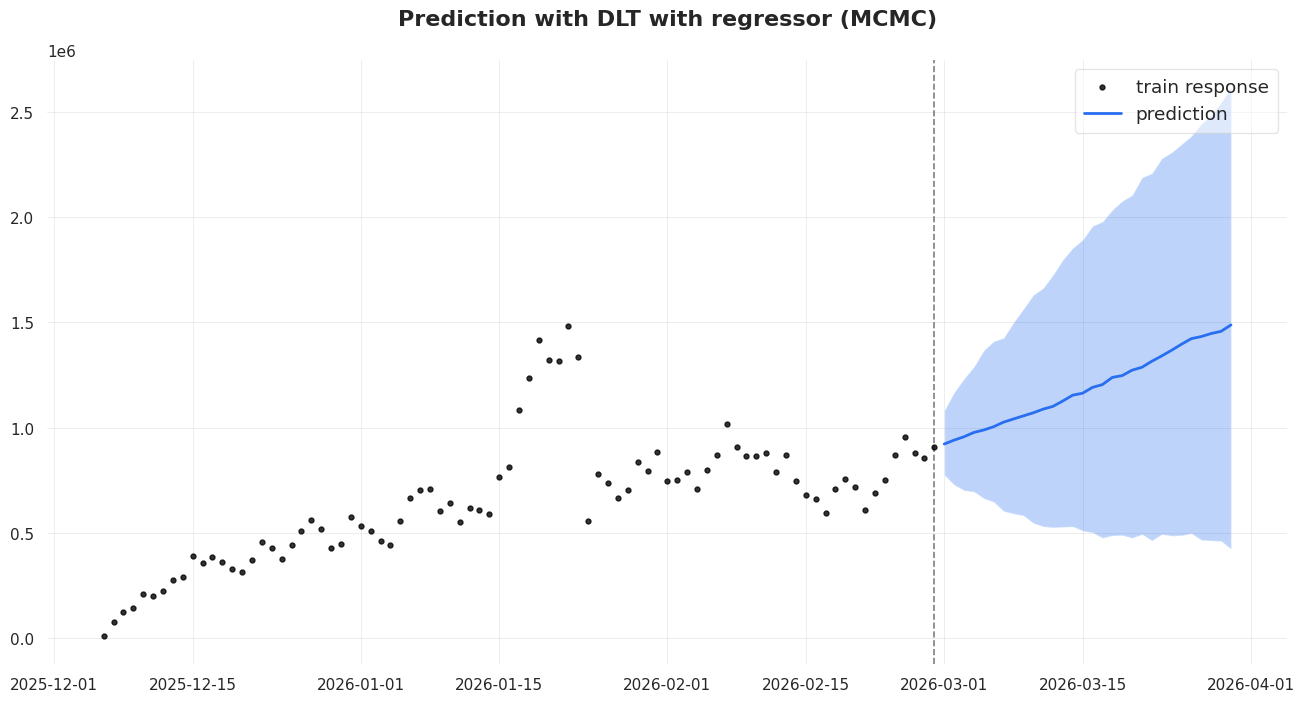

In [25]:
predicted_df_reg_mcmc = reg_model_mcmc.predict(df=future_df_reg_mcmc)

_ = plot_predicted_data(df, predicted_df_reg_mcmc, "day", 'actions', title='Prediction with DLT with regressor (MCMC)')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

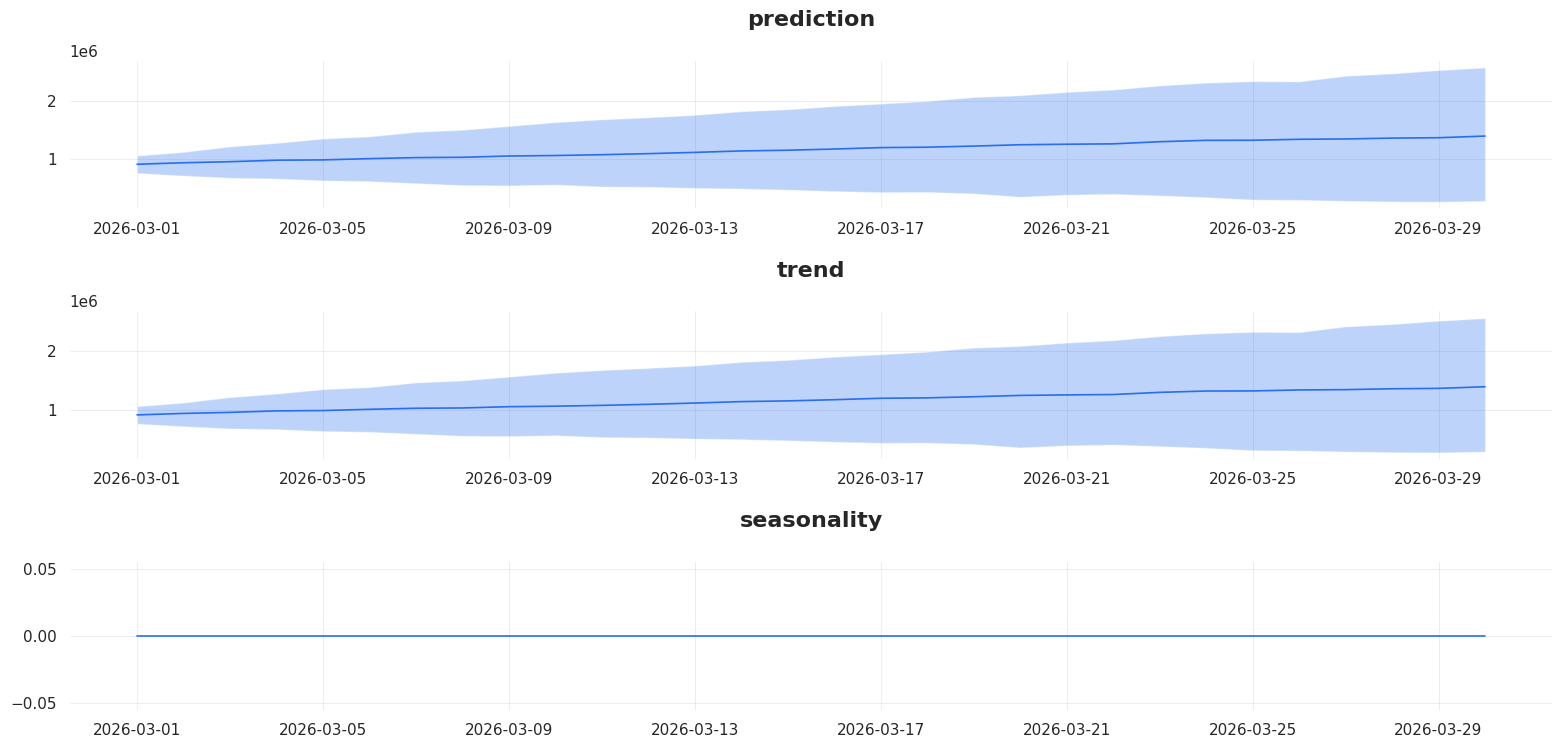

In [26]:
predicted_df_reg_mcmc = reg_model_mcmc.predict(df=future_df_reg_mcmc, decompose=True)

_ = plot_predicted_components(predicted_df_reg_mcmc, "day", plot_components=['prediction', 'trend', 'seasonality'])

Проверка моделей с помощью бэктестинга 

In [27]:
bt_exp = BackTester(
    model=dlt_mcmc, #наша модель
    df=df, #датафрейм для обучения
    min_train_len=14, #самый маленький кусочек данных, с которого начинается обучение
    incremental_len=1, #на сколько происходит прирост тренировочных данных
    forecast_len=30, #горизонт пронозирования
    window_type="expanding" #тип окна
)

In [28]:
bt_exp.fit_predict() #обучаем

2026-04-07 12:14:20 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

2026-04-07 12:16:05 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [29]:
bt_exp.score()

,metric_name,metric_values,is_training_metric
0,smape,3.813394e-01,False
1,wmape,4.917420e-01,False
2,mape,5.110986e-01,False
3,mse,3.354559e+11,False
4,mae,3.976287e+05,False
5,rmsse,3.267852e+00,False


In [30]:
bt_roll = BackTester(
    model=dlt_mcmc,
    df=df,
    min_train_len=7,
    incremental_len=7,
    forecast_len=30,
    window_type="rolling",
)

In [31]:
bt_roll.fit_predict()

2026-04-07 12:16:09 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

2026-04-07 12:16:16 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [32]:
bt_roll.score()

,metric_name,metric_values,is_training_metric
0,smape,4.879447e-01,False
1,wmape,6.557240e-01,False
2,mape,6.575599e-01,False
3,mse,4.599221e+11,False
4,mae,4.871789e+05,False
5,rmsse,4.352639e+00,False


In [33]:
models = {
    "dlt_map": dlt,
    "dlt_map_reg": reg_model,
    "dlt_mcmc": dlt_mcmc,
    "dlt_mcmc_reg": reg_model_mcmc
}

results = []

for name, model in models.items():
    bt = BackTester(
        model=model,
        df=df,
        min_train_len=7,
        incremental_len=1,
        forecast_len=30,
        window_type="expanding"
    )
    
    bt.fit_predict()
    score = bt.score()
    
    score["model"] = name
    results.append(score)

summary = pd.concat(results)
summary.set_index("model", inplace=True)

summary

2026-04-07 12:16:28 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

,metric_name,metric_values,is_training_metric
model,,,
dlt_map,smape,3.477028e-01,False
dlt_map,wmape,4.015461e-01,False
dlt_map,mape,4.243703e-01,False
dlt_map,mse,1.559312e+11,False
dlt_map,mae,3.074614e+05,False
dlt_map,rmsse,2.342881e+00,False
dlt_map_reg,smape,3.688346e-01,False
dlt_map_reg,wmape,4.386609e-01,False
dlt_map_reg,mape,4.620626e-01,False


In [34]:
summary

,metric_name,metric_values,is_training_metric
model,,,
dlt_map,smape,3.477028e-01,False
dlt_map,wmape,4.015461e-01,False
dlt_map,mape,4.243703e-01,False
dlt_map,mse,1.559312e+11,False
dlt_map,mae,3.074614e+05,False
dlt_map,rmsse,2.342881e+00,False
dlt_map_reg,smape,3.688346e-01,False
dlt_map_reg,wmape,4.386609e-01,False
dlt_map_reg,mape,4.620626e-01,False


Модель DLT MAP оказалась лучшей по метрикам оценки, но исходя из графиков она дает нулевой тренд. Проблема может быть в модели, настройках, горизонте.
DLT MAP с бинарным регрессором показывает сопоставимые, но немного худшие результаты. 

Все модели демонстрируют относительно высокий уровень ошибки (MAPE ~35–54%)

В качестве основной метрики выбрана MAPE, так как она отражает относительную ошибку прогноза и удобна для интерпретации в процентах. Дополнительно используется RMSE для оценки чувствительности моделей к крупным ошибкам.

Посмотрим, как модель MAP с регрессором предсказывает уже прошедшие события

In [35]:
train_dat = df.query("day < '2026-02-08'")
test_dat = df.query("day >= '2026-02-08'").astype({"unusual_day":"int64"})

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

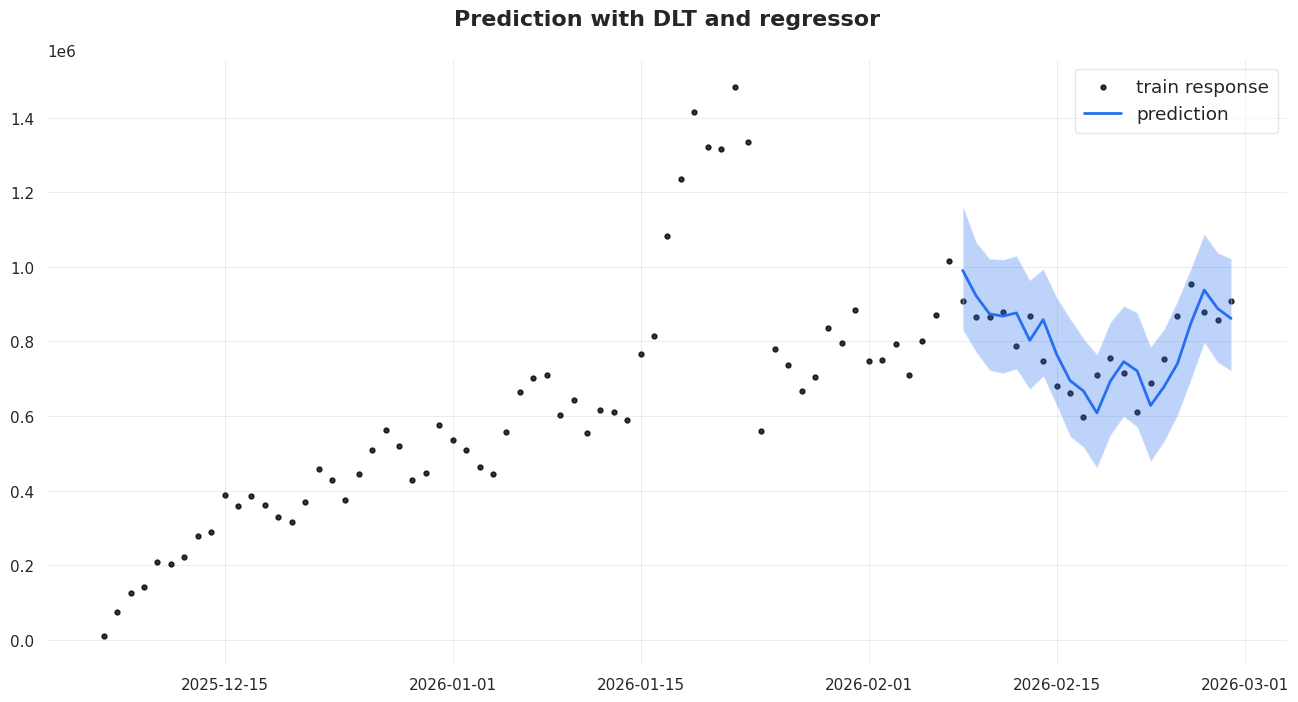

In [36]:
predicted_df_reg = reg_model.predict(df=test_dat)

_ = plot_predicted_data(df, predicted_df_reg, "day", 'actions', title='Prediction with DLT and regressor')

Модель показывает хороший результат.

Посмотрим, как модель MCMC с регрессором предсказвает уже прошедшие события

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

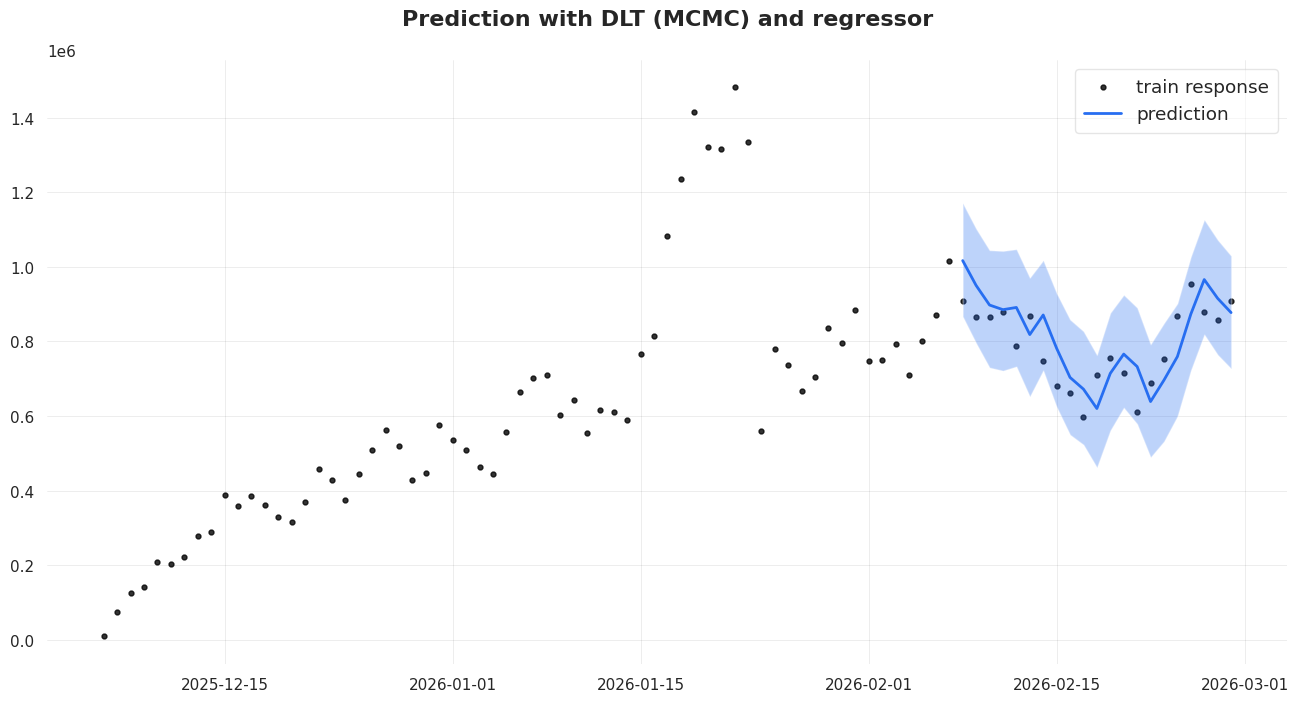

In [37]:
predicted_df_reg_mcmc = reg_model_mcmc.predict(df=test_dat)

_ = plot_predicted_data(df, predicted_df_reg_mcmc, "day", 'actions', title='Prediction with DLT (MCMC) and regressor')

Визуально тоже хороший результат, но по метрикам все же выигрывает алгоритм MAP, поэтому именно его я рекомендую.

Проверка модели с алгоритмом MCMC

In [38]:
params = dlt_mcmc.get_posterior_samples(permute=False)

array([[<Axes: title={'center': 'obs_sigma'}>,
        <Axes: title={'center': 'obs_sigma'}>]], dtype=object)

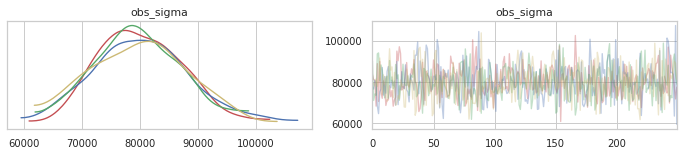

In [39]:
az.plot_trace(params, chain_prop={"color": ['r', 'b', 'g', 'y']}, var_names = "obs_sigma")